In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

from statsmodels.tsa.stattools import adfuller

import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")

print("All libraries loaded successfully")

All libraries loaded successfully


In [2]:
df = pd.read_csv('tesla_deliveries_dataset_2015_2025.csv')

print("Dataset Loaded Successfully")
print("\nShape of Dataset:")
print(df.shape)

print("\nColumns:")
print(df.columns.tolist())

Dataset Loaded Successfully

Shape of Dataset:
(2640, 12)

Columns:
['Year', 'Month', 'Region', 'Model', 'Estimated_Deliveries', 'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons', 'Source_Type', 'Charging_Stations']


In [3]:
df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   str    
 3   Model                 2640 non-null   str    
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   str    
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), str(3)
memory usage: 337.3 KB


In [5]:
df.describe()

,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,2020.000000,6.500000,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,8932.133712
std,3.162877,3.452707,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,3469.565883
min,2015.000000,1.000000,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,3002.000000
25%,2017.000000,3.750000,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,5897.750000
50%,2020.000000,6.500000,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,8901.500000
75%,2023.000000,9.250000,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,11938.000000
max,2025.000000,12.000000,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,14996.000000


In [6]:
print("Missing Values:\n")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

Missing Values:

Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64

Duplicate Rows:
0


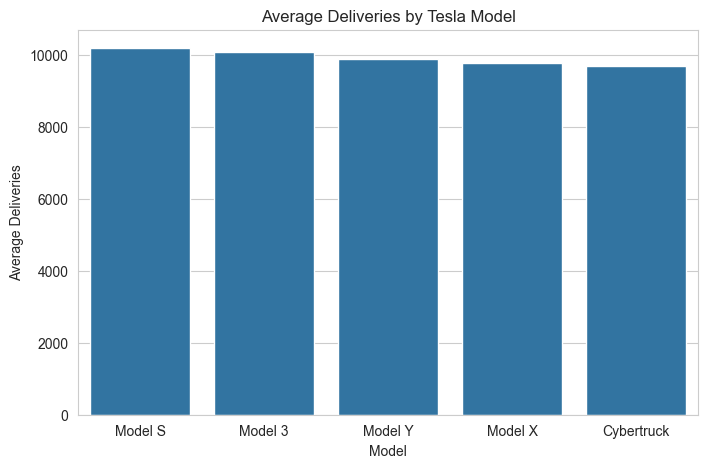

In [7]:
model_deliveries = (
    df.groupby("Model")["Estimated_Deliveries"]
      .mean()
      .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))

sns.barplot(
    x=model_deliveries.index,
    y=model_deliveries.values
)

plt.title("Average Deliveries by Tesla Model")

plt.xlabel("Model")

plt.ylabel("Average Deliveries")

plt.show()

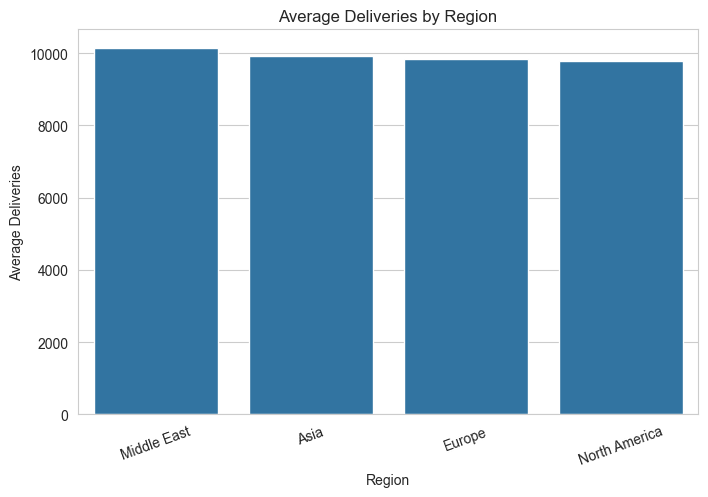

In [8]:
region_deliveries = (
    df.groupby("Region")["Estimated_Deliveries"]
      .mean()
      .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))

sns.barplot(
    x=region_deliveries.index,
    y=region_deliveries.values
)

plt.title("Average Deliveries by Region")

plt.xlabel("Region")

plt.ylabel("Average Deliveries")

plt.xticks(rotation=20)

plt.show()

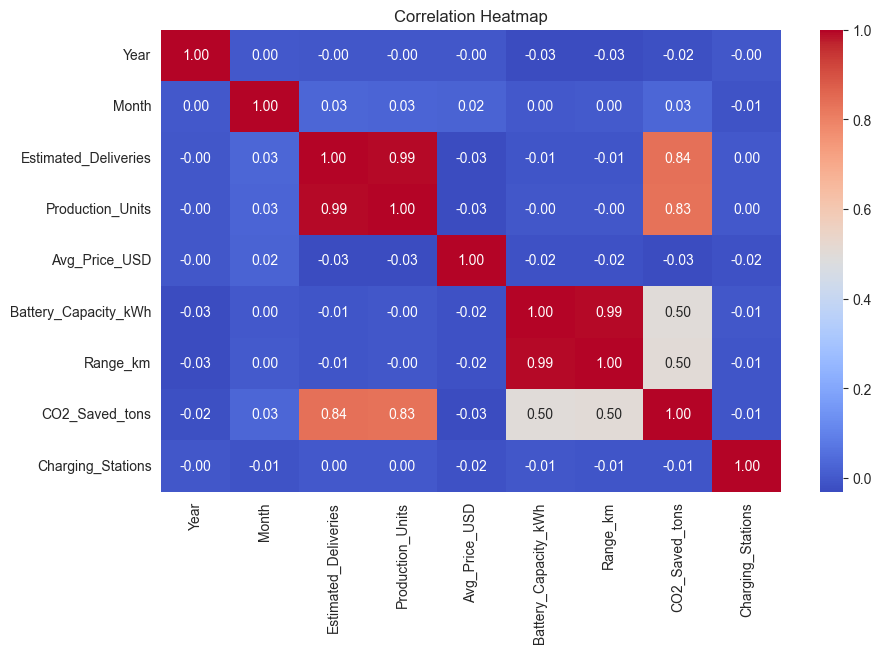

In [9]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(10,6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

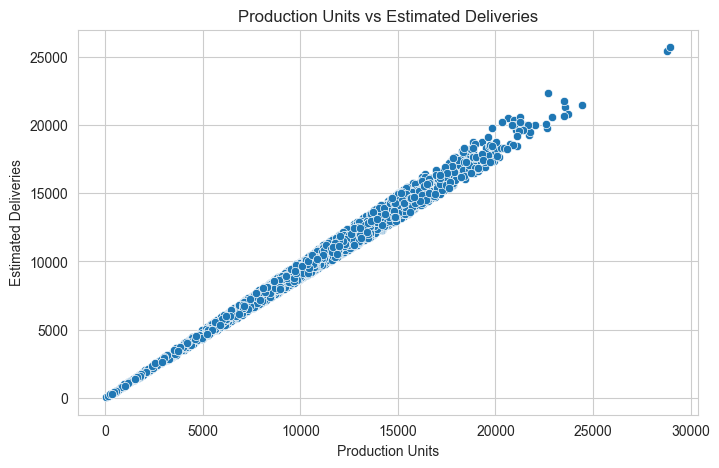

In [10]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x=df["Production_Units"],
    y=df["Estimated_Deliveries"]
)

plt.title("Production Units vs Estimated Deliveries")

plt.xlabel("Production Units")

plt.ylabel("Estimated Deliveries")

plt.show()

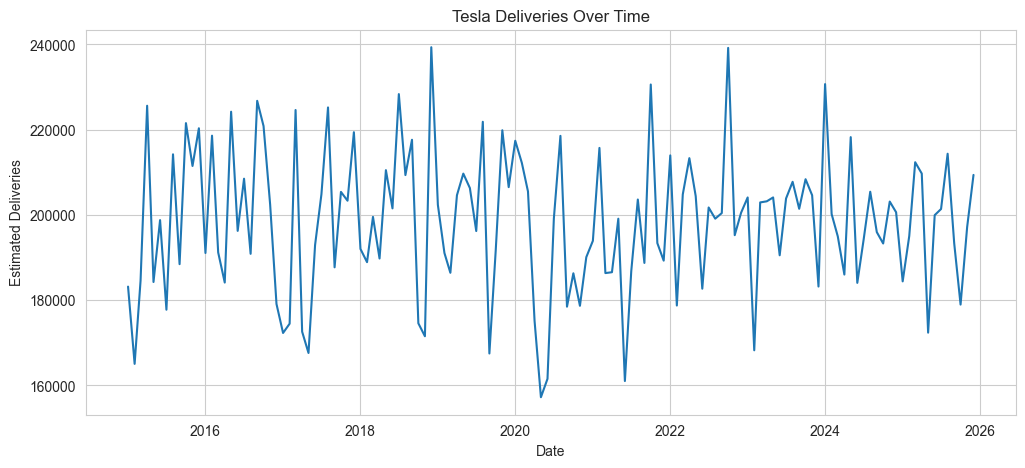

In [11]:
df["Date"] = pd.to_datetime(
    df["Year"].astype(str)
    + "-"
    + df["Month"].astype(str)
)

monthly_sales = (
    df.groupby("Date")["Estimated_Deliveries"]
      .sum()
)

plt.figure(figsize=(12,5))

plt.plot(
    monthly_sales.index,
    monthly_sales.values
)

plt.title("Tesla Deliveries Over Time")

plt.xlabel("Date")

plt.ylabel("Estimated Deliveries")

plt.show()

In [12]:
df_ml = df.copy()

encoder = LabelEncoder()

categorical_cols = [
    "Region",
    "Model",
    "Source_Type"
]

for col in categorical_cols:
    df_ml[col] = encoder.fit_transform(df_ml[col])

print("Categorical features encoded successfully")
df_ml.head()

Categorical features encoded successfully


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations,Date
0,2023,5,1,2,17646,17922,92874.27,120,704,1863.42,1,12207,2023-05-01
1,2015,2,0,3,3797,4164,62205.65,75,438,249.46,2,7640,2015-02-01
2,2019,1,3,3,8411,9189,117887.32,82,480,605.59,1,14071,2019-01-01
3,2021,2,3,1,6555,7311,89294.91,120,712,700.07,2,9333,2021-02-01
4,2016,12,2,4,12374,13537,114846.78,120,661,1226.88,0,8722,2016-12-01


In [13]:
df_ml = df_ml.sort_values(["Year", "Month"])

df_ml["Deliveries_Lag1"] = (
    df_ml["Estimated_Deliveries"]
    .shift(1)
)

df_ml["Deliveries_Lag1"].fillna(
    df_ml["Deliveries_Lag1"].mean(),
    inplace=True
)

print("Lag Feature Created")
df_ml[["Estimated_Deliveries", "Deliveries_Lag1"]].head()

Lag Feature Created


,Estimated_Deliveries,Deliveries_Lag1
644,10348,NaN
872,12446,10348.0
904,10835,12446.0
1199,8122,10835.0
1228,13902,8122.0


In [14]:
df_ml["Rolling_Mean_3"] = (
    df_ml["Estimated_Deliveries"]
    .rolling(window=3)
    .mean()
)

df_ml["Rolling_Mean_3"].fillna(
    df_ml["Rolling_Mean_3"].mean(),
    inplace=True
)

print("Rolling Mean Feature Created")
df_ml[
    ["Estimated_Deliveries", "Rolling_Mean_3"]
].head()

Rolling Mean Feature Created


,Estimated_Deliveries,Rolling_Mean_3
644,10348,NaN
872,12446,NaN
904,10835,11209.666667
1199,8122,10467.666667
1228,13902,10953.000000


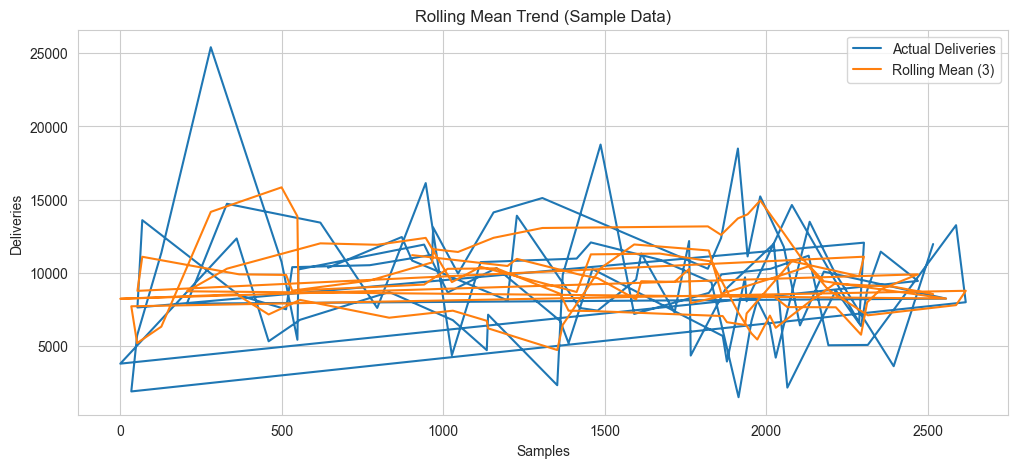

In [15]:
plt.figure(figsize=(12,5))

sample_df = df_ml.head(100)

plt.plot(
    sample_df["Estimated_Deliveries"],
    label="Actual Deliveries"
)

plt.plot(
    sample_df["Rolling_Mean_3"],
    label="Rolling Mean (3)"
)

plt.title("Rolling Mean Trend (Sample Data)")
plt.xlabel("Samples")
plt.ylabel("Deliveries")
plt.legend()

plt.show()

In [16]:
target = "Estimated_Deliveries"

features = [
    "Year",
    "Month",
    "Region",
    "Model",
    "Production_Units",
    "Avg_Price_USD",
    "Battery_Capacity_kWh",
    "Range_km",
    "CO2_Saved_tons",
    "Source_Type",
    "Charging_Stations",
    "Deliveries_Lag1",
    "Rolling_Mean_3"
]

X = df_ml[features]
y = df_ml[target]

print(X.shape)
print(y.shape)

(2640, 13)
(2640,)


In [17]:
split_index = int(len(df_ml) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Train Size:", len(X_train))
print("Test Size:", len(X_test))

Train Size: 2112
Test Size: 528


In [18]:
X_train = X_train.fillna(X_train.mean())   

In [19]:
lr = LinearRegression()

lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)

print("Linear Regression Model Trained Successfully")

Linear Regression Model Trained Successfully


In [20]:
mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(
    mean_squared_error(y_test, y_pred)
)

r2 = r2_score(y_test, y_pred)

print("MAE :", round(mae,2))
print("RMSE:", round(rmse,2))
print("R² :", round(r2,4))

MAE : 317.93
RMSE: 386.69
R² : 0.9889


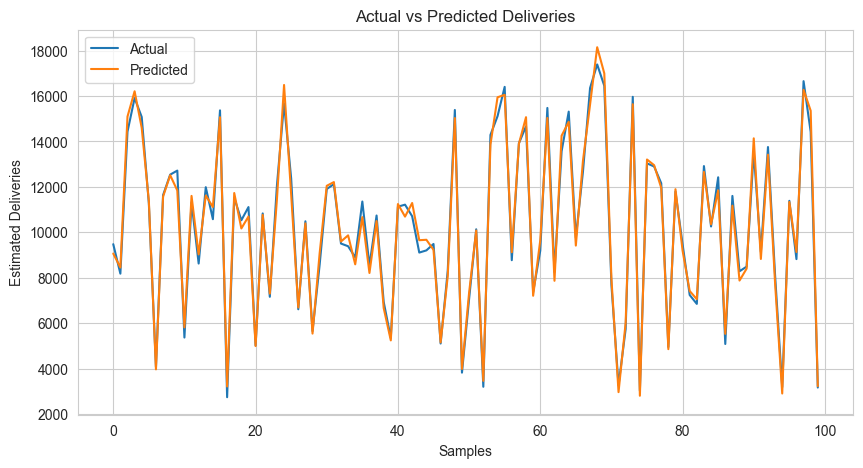

In [21]:
plt.figure(figsize=(10,5))

plt.plot(
    y_test.values[:100],
    label="Actual"
)

plt.plot(
    y_pred[:100],
    label="Predicted"
)

plt.title("Actual vs Predicted Deliveries")

plt.xlabel("Samples")

plt.ylabel("Estimated Deliveries")

plt.legend()

plt.show()

In [22]:
X = X.fillna(X.mean())   

In [23]:
kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_scores = cross_val_score(
    lr,
    X,
    y,
    cv=kf,
    scoring="r2"
)

print("Cross Validation Scores:")
print(cv_scores)

print("\nAverage R²:")
print(cv_scores.mean())

Cross Validation Scores:
[0.99079057 0.99051885 0.98970067 0.99023446 0.99037022]

Average R²:
0.990322953493124


In [24]:
rf = RandomForestRegressor(
    random_state=42
)

param_grid = {
    "n_estimators":[50,100],
    "max_depth":[5,10,None]
}

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=3,
    scoring="r2",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:")
print(grid_search.best_params_)

Best Parameters:
{'max_depth': 10, 'n_estimators': 100}


In [25]:
best_rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    random_state=42
)

best_rf.fit(X_train, y_train)

rf_pred = best_rf.predict(X_test)

print("Random Forest Model Trained Successfully")

Random Forest Model Trained Successfully


In [26]:
rf_mae = mean_absolute_error(y_test, rf_pred)

rf_rmse = np.sqrt(
    mean_squared_error(y_test, rf_pred)
)

rf_r2 = r2_score(
    y_test,
    rf_pred
)

print("Random Forest Results")
print("---------------------")
print("MAE :", round(rf_mae,2))
print("RMSE:", round(rf_rmse,2))
print("R²  :", round(rf_r2,4))

Random Forest Results
---------------------
MAE : 337.18
RMSE: 414.67
R²  : 0.9872


In [27]:
adf_result = adfuller(df["Estimated_Deliveries"])

print("ADF Statistic:", adf_result[0])
print("P-Value:", adf_result[1])

if adf_result[1] < 0.05:
    print("Series is Stationary")
else:
    print("Series is Non-Stationary")

ADF Statistic: -53.82661259715622
P-Value: 0.0
Series is Stationary


In [28]:
forecast_df = pd.DataFrame({
    "Actual": y_test.values[:20],
    "Predicted": y_pred[:20]
})

forecast_df

,Actual,Predicted
0,9476,9063.528534
1,8179,8448.374485
2,14430,15095.699352
3,15912,16210.487665
4,15077,14598.067590
5,11280,11383.731460
6,4070,3964.098957
7,11636,11572.280553
8,12540,12514.508441
9,12717,11842.113503
